# Fashion Type Dataset Improvement

## 1. Objective

The objective of this notebook is to improve the clothing type classifier by adding targeted real-world-like training images.

Previous experiments showed that the current clothing type classifier performs strongly on the curated dataset, but still makes mistakes on realistic input images. This became especially important in the recommendation pipeline, because the recommender depends on the predicted clothing type to exclude the input item category.

For example, if an input jacket is incorrectly predicted as a tshirt, the recommender excludes tshirts instead of jackets. This can result in the system recommending another jacket, which breaks the intended outfit structure.

This notebook therefore focuses on improving the clothing type classifier using extra targeted data for the weakest real-world cases.

The four clothing type classes are:

- jacket
- pants
- shoes
- tshirt

The goal is to test whether adding targeted real-world-like images improves type classification performance, especially on the real-world test set.

## 2. Project Context

The outfit recommendation system uses two classification models before generating recommendations:

1. a style classifier
2. a clothing type classifier

The style classifier predicts the visual style of the input item, such as formal, gothic, sporty, or streetwear. The clothing type classifier predicts the item category, such as jacket, pants, shoes, or tshirt.

The recommender then uses these predictions to retrieve items with the same predicted style, while excluding items with the same predicted clothing type. This means that type prediction is structurally important. If the predicted type is wrong, the system may exclude the wrong category and recommend an item that has the same actual type as the input image.

Earlier results showed that the clothing type classifier achieved strong results on clean data:

- 1.00 internal test accuracy
- 0.90 small external test accuracy
- 0.7500 real-world test accuracy

Although the type classifier is more reliable than the style classifier, the real-world recommendation examples showed that type errors can still create serious recommendation problems. Because of this, the next improvement focuses on the type classifier.

This experiment follows the same logic as the previous style dataset improvement experiment. Instead of changing the model architecture first, the dataset is improved by adding targeted images that represent the types of cases where the system previously struggled.

## 3. Approach

This notebook improves the type classifier by adding a new extra training dataset called `type_extra`.

The extra dataset contains targeted real-world-like examples for the four clothing type classes:

- jacket
- tshirt
- pants
- shoes

The focus is mainly on jackets and tshirts because previous recommendation examples showed that mistakes between these categories can directly break the recommendation structure.

The planned extra dataset contains approximately:

| Type | Extra images | Reason |
|---|---:|---|
| jacket | 30 | Important failure category in real-world recommendation examples |
| tshirt | 30 | Often visually overlaps with jackets or upper-body clothing |
| pants | 15 | Added for extra real-world variation |
| shoes | 15 | Already stronger, but included to keep all classes represented |

The improved type model is trained using:

- the original type training split
- the new `type_extra` dataset

The model architecture and training strategy stay the same as the original type baseline:

- pretrained ResNet34
- frozen feature extractor
- replaced final classification layer
- trained final layer only

This is intentional. The experiment is designed to test whether targeted data improvement helps real-world generalization without changing the model architecture.

## 4. Import Libraries

The notebook uses PyTorch and torchvision for image classification, pandas for result summaries, matplotlib for visualization, and sklearn for evaluation metrics.

The same reproducibility setup as previous experiments is used so that the training process remains as consistent as possible.

In [1]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

torch version: 2.11.0+cu130
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: CUDA


## 5. Dataset Paths and Results Folder

This notebook uses the original clothing type dataset split together with the new targeted extra dataset.

The original type split is used for training, validation, and curated test evaluation. The `type_extra` folder is added only to the training data. The validation and test sets are not changed, so the evaluation remains fair.

The notebook also evaluates the improved model on the external type test set and the real-world test set.

In [2]:
# Original type dataset paths
train_dir = "../dataset/split_type/train"
val_dir = "../dataset/split_type/val"
test_dir = "../dataset/split_type/test"

# Extra targeted type dataset
type_extra_dir = "../dataset/type_extra"

# Additional evaluation datasets
external_type_test_dir = "../dataset/external_type_test"
real_world_test_dir = "../dataset/real_world_test"

# Output folders
results_dir = "../results/type_dataset_improvement"
models_dir = "../models"

os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

print("Original train path:", train_dir)
print("Validation path:", val_dir)
print("Curated test path:", test_dir)
print("Type extra path:", type_extra_dir)
print("External type test path:", external_type_test_dir)
print("Real-world test path:", real_world_test_dir)
print("Results folder:", results_dir)
print("Models folder:", models_dir)

Original train path: ../dataset/split_type/train
Validation path: ../dataset/split_type/val
Curated test path: ../dataset/split_type/test
Type extra path: ../dataset/type_extra
External type test path: ../dataset/external_type_test
Real-world test path: ../dataset/real_world_test
Results folder: ../results/type_dataset_improvement
Models folder: ../models


## 6. Image Transforms

The same preprocessing style as the baseline experiments is used.

Training images are resized to 224 by 224 pixels, randomly flipped, converted to tensors, and normalized using ImageNet statistics. The validation and test images use deterministic preprocessing without augmentation.

Only the training data receives augmentation because validation and test results should represent stable evaluation conditions.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 7. Load Original and Extra Datasets

The original type training dataset and the new `type_extra` dataset are loaded using `ImageFolder`.

The extra dataset must use the same class folder names as the original type split:

- jacket
- pants
- shoes
- tshirt

Before combining the datasets, the class names are checked to make sure that the label mapping is the same. This is important because PyTorch assigns numeric labels based on folder names. If the class order is inconsistent, the model would learn incorrect labels.

In [4]:
# Load original datasets
train_dataset_original = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# Load extra training dataset
type_extra_dataset = datasets.ImageFolder(type_extra_dir, transform=train_transform)

# Class names
class_names = train_dataset_original.classes
num_classes = len(class_names)

print("Original type classes:", train_dataset_original.classes)
print("Type extra classes:", type_extra_dataset.classes)
print("Validation classes:", val_dataset.classes)
print("Test classes:", test_dataset.classes)

assert train_dataset_original.classes == type_extra_dataset.classes, "Class mismatch between original train and type_extra."
assert train_dataset_original.classes == val_dataset.classes, "Class mismatch between train and validation."
assert train_dataset_original.classes == test_dataset.classes, "Class mismatch between train and test."

print("\nClass mapping is consistent.")
print("Classes:", class_names)
print("Number of classes:", num_classes)

Original type classes: ['jacket', 'pants', 'shoes', 'tshirt']
Type extra classes: ['jacket', 'pants', 'shoes', 'tshirt']
Validation classes: ['jacket', 'pants', 'shoes', 'tshirt']
Test classes: ['jacket', 'pants', 'shoes', 'tshirt']

Class mapping is consistent.
Classes: ['jacket', 'pants', 'shoes', 'tshirt']
Number of classes: 4


## 8. Dataset Overview

Before combining the datasets, the original type split and the extra dataset are inspected.

This helps confirm:

- the original split was loaded correctly
- the extra dataset has the expected number of images
- the class distribution is understandable before training

In [5]:
def count_images_per_class(dataset):
    counts = {class_name: 0 for class_name in dataset.classes}

    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] += 1

    return counts

In [6]:
original_train_counts = count_images_per_class(train_dataset_original)
extra_counts = count_images_per_class(type_extra_dataset)
val_counts = count_images_per_class(val_dataset)
test_counts = count_images_per_class(test_dataset)

dataset_size_summary = pd.DataFrame({
    "Original Train": original_train_counts,
    "Type Extra": extra_counts,
    "Validation": val_counts,
    "Curated Test": test_counts
})

dataset_size_summary

,Original Train,Type Extra,Validation,Curated Test
jacket,140,30,30,30
pants,140,15,30,30
shoes,140,15,30,30
tshirt,140,30,30,30


### 8.1. Split Summary

The table below shows the number of images in the original training set, the extra training set, the combined training set, validation set, and curated test set.

In [7]:
combined_train_size = len(train_dataset_original) + len(type_extra_dataset)

split_summary = pd.DataFrame({
    "Dataset": [
        "Original Train",
        "Type Extra",
        "Combined Train",
        "Validation",
        "Curated Test"
    ],
    "Images": [
        len(train_dataset_original),
        len(type_extra_dataset),
        combined_train_size,
        len(val_dataset),
        len(test_dataset)
    ]
})

split_summary

,Dataset,Images
0,Original Train,560
1,Type Extra,90
2,Combined Train,650
3,Validation,120
4,Curated Test,120


## 9. Combine Original Training Data and Type Extra Data

The improved training dataset is created by combining the original type training split with the new targeted `type_extra` dataset.

Only the training data is expanded. The validation and test sets remain unchanged. This keeps the evaluation fair because the model is still tested on images it did not see during training.

In [8]:
combined_train_dataset = ConcatDataset([
    train_dataset_original,
    type_extra_dataset
])

batch_size = 16

train_loader = DataLoader(
    combined_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Combined training images:", len(combined_train_dataset))
print("Validation images:", len(val_dataset))
print("Curated test images:", len(test_dataset))

Combined training images: 650
Validation images: 120
Curated test images: 120


## 10. Sample Images from Type Extra Dataset

A few images from the extra dataset are visualized before training.

This step is important because the extra data is manually collected. Visual inspection helps confirm that the labels make sense and that the images are suitable for improving real-world generalization.

In [9]:
def show_images_per_class(dataset, class_names, images_per_class=3):
    fig, axes = plt.subplots(
        len(class_names),
        images_per_class,
        figsize=(4 * images_per_class, 4 * len(class_names))
    )

    if len(class_names) == 1:
        axes = np.expand_dims(axes, axis=0)

    class_indices = {i: [] for i in range(len(class_names))}

    for idx, (_, label) in enumerate(dataset.samples):
        if len(class_indices[label]) < images_per_class:
            class_indices[label].append(idx)

        if all(len(indices) == images_per_class for indices in class_indices.values()):
            break

    for class_idx, indices in class_indices.items():
        for j, sample_idx in enumerate(indices):
            image, label = dataset[sample_idx]

            image = image.permute(1, 2, 0).numpy()
            image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            image = np.clip(image, 0, 1)

            axes[class_idx, j].imshow(image)
            axes[class_idx, j].set_title(class_names[label])
            axes[class_idx, j].axis("off")

    plt.tight_layout()
    plt.show()

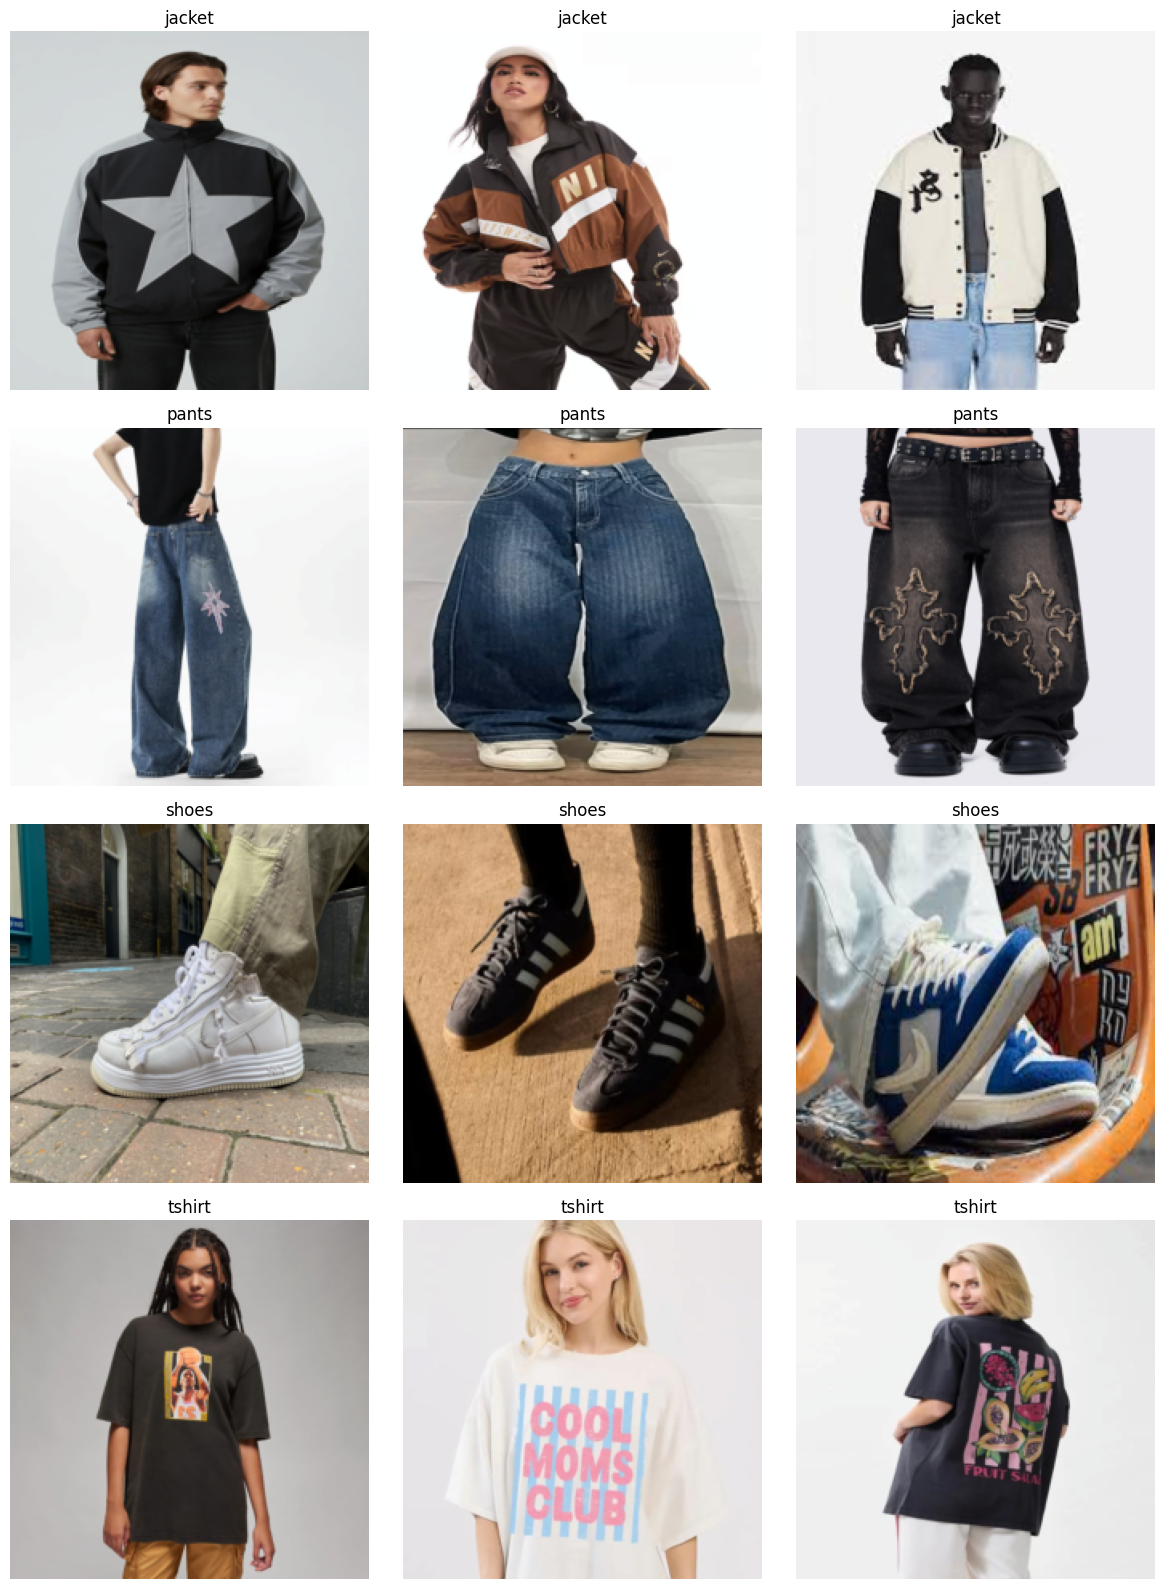

In [10]:
show_images_per_class(type_extra_dataset, class_names, images_per_class=3)

## 11. Model Selection

The improved type classifier uses the same architecture as the original type baseline: a pretrained ResNet34 model.

This is intentional because the goal of this experiment is to test the impact of targeted dataset improvement, not to test a different architecture. By keeping the model architecture and training strategy the same, the results can be compared more fairly with the original type classifier.

The pretrained ResNet34 model is loaded with ImageNet weights, and the final classification layer is replaced so that the model predicts the four clothing type classes:

- jacket
- pants
- shoes
- tshirt

In [11]:
# Load pretrained ResNet34
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Replace the final classification layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Move model to device
model = model.to(device)

print("ResNet34 model loaded.")
print("Number of output classes:", num_classes)

ResNet34 model loaded.
Number of output classes: 4


## 12. Training Configuration

The pretrained feature extractor is frozen and only the final classification layer is trained.

This matches the original type baseline experiment and keeps the comparison focused on the effect of the added `type_extra` dataset.

The model is trained using:

- CrossEntropyLoss
- Adam optimizer
- 10 training epochs

The validation set is monitored after each epoch to check whether the added data improves learning without damaging generalization.

In [12]:
# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Training settings
num_epochs = 10

print("Training only the final classification layer.")
print("Number of epochs:", num_epochs)

Training only the final classification layer.
Number of epochs: 10


## 13. Training and Validation Loop

The model is trained using the combined training dataset, which contains the original type training images and the new targeted extra images.

After each epoch, the model is evaluated on the unchanged validation set. This makes it possible to check whether the model is learning useful patterns from the extra data while still generalizing to unseen validation images.

In [13]:
# Lists to store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_state = None

for epoch in range(num_epochs):
    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

print("\nBest validation accuracy:", round(best_val_accuracy, 4))

Epoch [1/10] | Train Loss: 1.0134 | Train Acc: 0.6185 | Val Loss: 0.5237 | Val Acc: 0.8917
Epoch [2/10] | Train Loss: 0.5003 | Train Acc: 0.8754 | Val Loss: 0.2780 | Val Acc: 0.9583
Epoch [3/10] | Train Loss: 0.3382 | Train Acc: 0.9231 | Val Loss: 0.2119 | Val Acc: 0.9583
Epoch [4/10] | Train Loss: 0.2993 | Train Acc: 0.9123 | Val Loss: 0.1554 | Val Acc: 0.9833
Epoch [5/10] | Train Loss: 0.2655 | Train Acc: 0.9215 | Val Loss: 0.1293 | Val Acc: 0.9833
Epoch [6/10] | Train Loss: 0.2269 | Train Acc: 0.9277 | Val Loss: 0.1129 | Val Acc: 0.9833
Epoch [7/10] | Train Loss: 0.1927 | Train Acc: 0.9569 | Val Loss: 0.1049 | Val Acc: 0.9833
Epoch [8/10] | Train Loss: 0.1703 | Train Acc: 0.9554 | Val Loss: 0.0968 | Val Acc: 0.9750
Epoch [9/10] | Train Loss: 0.1671 | Train Acc: 0.9585 | Val Loss: 0.0875 | Val Acc: 0.9833
Epoch [10/10] | Train Loss: 0.1304 | Train Acc: 0.9723 | Val Loss: 0.0730 | Val Acc: 0.9917

Best validation accuracy: 0.9917


### 13.1. Load Best Validation Model

The best model state based on validation accuracy is restored before final evaluation.

This prevents the final evaluation from depending only on the last epoch if an earlier epoch performed better on the validation set.

In [14]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Best validation model state loaded.")
else:
    print("No best model state found. Using final epoch model.")

Best validation model state loaded.


## 14. Training History

After training, the recorded loss and accuracy values are visualized to better understand how the improved type classifier behaved across epochs.

The training and validation curves help show whether the model learned useful patterns from the combined dataset and whether signs of overfitting appeared during training.

### 14.1. Loss Plot

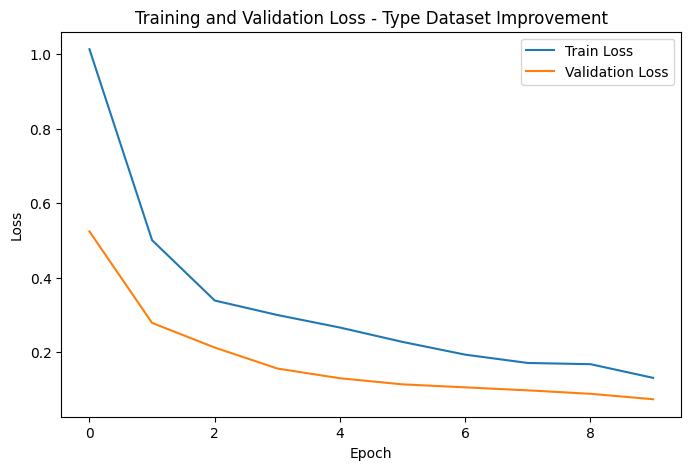

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss - Type Dataset Improvement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 14.2. Accuracy Plot

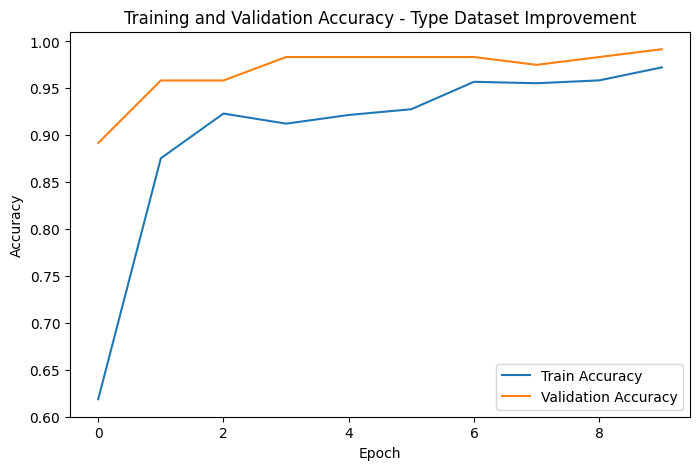

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training and Validation Accuracy - Type Dataset Improvement")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 15. Evaluation Helper Function

A reusable evaluation function is created so the improved model can be tested consistently on multiple datasets.

The function returns the model accuracy, predictions, true labels, classification report, and confusion matrix.

This avoids repeating the same evaluation logic for the curated test set, external type test set, and real-world test set.

In [17]:
def evaluate_model(model, data_loader, class_names):
    model.eval()

    all_preds = []
    all_labels = []

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total

    report_dict = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "accuracy": accuracy,
        "predictions": all_preds,
        "labels": all_labels,
        "report_dict": report_dict,
        "confusion_matrix": cm
    }

## 16. Curated Type Test Set Evaluation

The improved type classifier is first evaluated on the original curated type test split.

This test set was not changed during the dataset improvement experiment. This is important because it allows the improved model to be compared fairly with the original type baseline.

The goal of this step is to check whether adding targeted real-world-like images preserved performance on the clean curated dataset.

In [18]:
curated_results = evaluate_model(model, test_loader, class_names)

curated_accuracy = curated_results["accuracy"]
curated_preds = curated_results["predictions"]
curated_labels = curated_results["labels"]
curated_cm = curated_results["confusion_matrix"]

print(f"Curated Type Test Accuracy: {curated_accuracy:.4f}")

Curated Type Test Accuracy: 1.0000


### 16.1. Classification Report

In [19]:
print(classification_report(
    curated_labels,
    curated_preds,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

      jacket       1.00      1.00      1.00        30
       pants       1.00      1.00      1.00        30
       shoes       1.00      1.00      1.00        30
      tshirt       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



### 16.2. Confusion Matrix

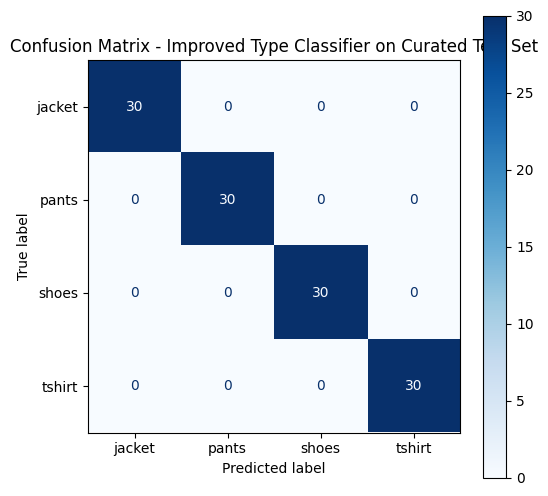

In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=curated_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Improved Type Classifier on Curated Test Set")
plt.show()

## 17. External Type Test Evaluation

The improved type classifier is next evaluated on the external type test set.

This test set was created after the original type classifier achieved perfect accuracy on the curated test split. Its purpose is to check whether the classifier can generalize to images outside the original curated train, validation, and test split.

This evaluation is important because the curated test set is clean and visually similar to the original dataset. The external type test set provides a stronger check of whether the improved model performs well on less familiar images.

In [21]:
external_type_test_dataset = datasets.ImageFolder(
    external_type_test_dir,
    transform=eval_transform
)

print("External type test classes:", external_type_test_dataset.classes)
print("Number of external type test images:", len(external_type_test_dataset))

assert external_type_test_dataset.classes == class_names, "Class mismatch in external type test set."

external_type_test_loader = DataLoader(
    external_type_test_dataset,
    batch_size=batch_size,
    shuffle=False
)

External type test classes: ['jacket', 'pants', 'shoes', 'tshirt']
Number of external type test images: 20


### 17.1. External Type Test Results

In [22]:
external_results = evaluate_model(
    model,
    external_type_test_loader,
    class_names
)

external_accuracy = external_results["accuracy"]
external_preds = external_results["predictions"]
external_labels = external_results["labels"]
external_cm = external_results["confusion_matrix"]

print(f"External Type Test Accuracy: {external_accuracy:.4f}")

External Type Test Accuracy: 0.9000


### 17.2. Classification Report

In [23]:
print(classification_report(
    external_labels,
    external_preds,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

      jacket       0.71      1.00      0.83         5
       pants       1.00      0.80      0.89         5
       shoes       1.00      0.80      0.89         5
      tshirt       1.00      1.00      1.00         5

    accuracy                           0.90        20
   macro avg       0.93      0.90      0.90        20
weighted avg       0.93      0.90      0.90        20



### 17.3. Confusion Matrix

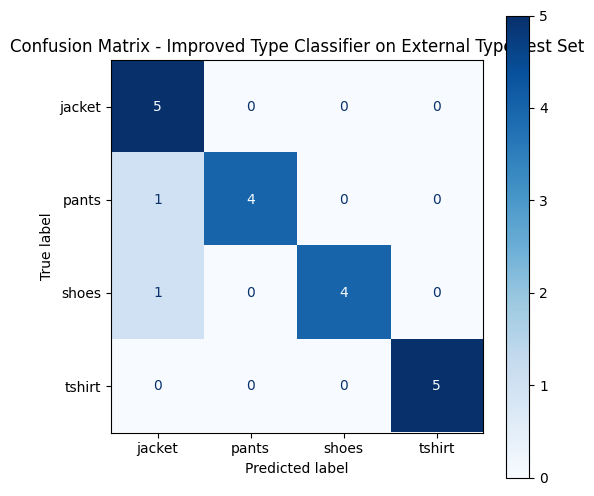

In [24]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=external_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Improved Type Classifier on External Type Test Set")
plt.show()

## 18. Real-World Type Evaluation

The improved type classifier is now evaluated on the real-world test set.

This is the most important evaluation for this experiment because the previous recommendation failures happened on realistic input images. The real-world test set contains more varied images, including worn clothing, different backgrounds, and less controlled visual conditions.

Unlike the curated type split, the real-world test folder is organized by both style and type:

real_world_test/style/type/image

For type evaluation, the true label is taken from the second folder level, which represents the clothing type.

In [25]:
from torch.utils.data import Dataset
from PIL import Image

In [26]:
class RealWorldTypeDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.root_dir = root_dir
        self.class_names = class_names
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        self.transform = transform
        self.samples = []

        valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

        for style_name in sorted(os.listdir(root_dir)):
            style_path = os.path.join(root_dir, style_name)

            if not os.path.isdir(style_path):
                continue

            for type_name in sorted(os.listdir(style_path)):
                type_path = os.path.join(style_path, type_name)

                if not os.path.isdir(type_path):
                    continue

                if type_name not in self.class_to_idx:
                    continue

                for filename in sorted(os.listdir(type_path)):
                    if filename.lower().endswith(valid_extensions):
                        image_path = os.path.join(type_path, filename)
                        label = self.class_to_idx[type_name]

                        self.samples.append((image_path, label, style_name, type_name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label, style_name, type_name = self.samples[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [27]:
real_world_type_dataset = RealWorldTypeDataset(
    root_dir=real_world_test_dir,
    class_names=class_names,
    transform=eval_transform
)

real_world_type_loader = DataLoader(
    real_world_type_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Number of real-world test images:", len(real_world_type_dataset))
print("Class names:", class_names)

Number of real-world test images: 80
Class names: ['jacket', 'pants', 'shoes', 'tshirt']


### 18.1. Real-World Type Test Results

In [28]:
real_world_results = evaluate_model(
    model,
    real_world_type_loader,
    class_names
)

real_world_accuracy = real_world_results["accuracy"]
real_world_preds = real_world_results["predictions"]
real_world_labels = real_world_results["labels"]
real_world_cm = real_world_results["confusion_matrix"]

print(f"Real-World Type Test Accuracy: {real_world_accuracy:.4f}")

Real-World Type Test Accuracy: 0.8875


### 18.2. Classification Report

In [29]:
print(classification_report(
    real_world_labels,
    real_world_preds,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

      jacket       0.73      0.95      0.83        20
       pants       1.00      0.75      0.86        20
       shoes       1.00      1.00      1.00        20
      tshirt       0.89      0.85      0.87        20

    accuracy                           0.89        80
   macro avg       0.91      0.89      0.89        80
weighted avg       0.91      0.89      0.89        80



### 18.3. Confusion Matrix

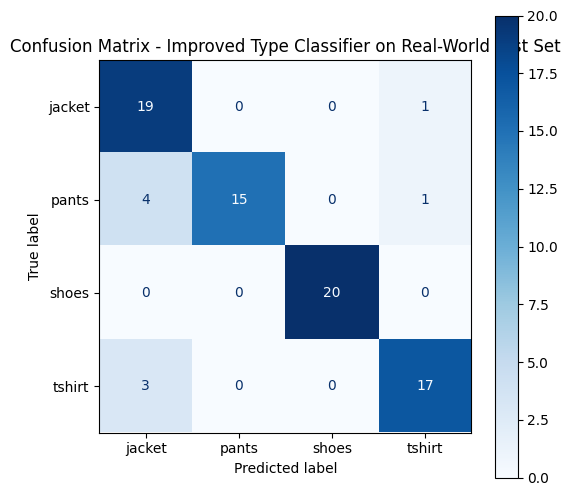

In [30]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=real_world_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Improved Type Classifier on Real-World Test Set")
plt.show()

### 18.4. Real-World Type Evaluation Interpretation

The improved type classifier achieved a real-world test accuracy of **0.8875**.

This is a clear improvement compared with the original type classifier, which achieved **0.7500** on the same real-world evaluation set. This suggests that adding targeted real-world-like training images helped the model generalize better to realistic input images.

The strongest class was **shoes**, with perfect precision, recall, and F1-score. Jackets also improved strongly in terms of recall, with 19 out of 20 real-world jacket images classified correctly.

The remaining errors mainly involve pants and tshirts being predicted as jackets:

- 4 pants images were predicted as jackets
- 3 tshirt images were predicted as jackets
- 1 jacket image was predicted as tshirt
- 1 pants image was predicted as tshirt

This shows that the model now recognizes jackets more strongly, but it may also overpredict the jacket class in some ambiguous real-world cases. However, the overall result is still much better than the previous real-world type performance.

For the recommendation system, this improvement is important because clothing type prediction controls which item category is excluded from the recommendation candidates. A stronger type classifier reduces the risk of excluding the wrong category and recommending another item of the same actual type.

## 19. Comparison With Original Type Model

The improved type classifier is compared with the original type baseline model.

The purpose of this comparison is to check whether the targeted extra training data improved real-world generalization while preserving performance on the curated and external test sets.

The original model results are taken from the previous type classification and real-world evaluation experiments.

In [31]:
comparison_results = pd.DataFrame([
    {
        "Model": "Original type model",
        "Training data": "Original split_type train set",
        "Curated type test accuracy": 1.0000,
        "External type test accuracy": 0.9000,
        "Real-world type test accuracy": 0.7500
    },
    {
        "Model": "Improved type model",
        "Training data": "Original split_type train set + type_extra",
        "Curated type test accuracy": curated_accuracy,
        "External type test accuracy": external_accuracy,
        "Real-world type test accuracy": real_world_accuracy
    }
])

comparison_results

,Model,Training data,Curated type test accuracy,External type test accuracy,Real-world type test accuracy
0,Original type model,Original split_type train set,1.0,0.9,0.7500
1,Improved type model,Original split_type train set + type_extra,1.0,0.9,0.8875


### 19.1. Comparison Interpretation

The comparison shows that the improved type classifier preserved the original model's performance on the curated and external test sets.

The curated type test accuracy stayed at **1.0000**, and the external type test accuracy stayed at **0.9000**. This means that the added `type_extra` images did not damage performance on the cleaner evaluation sets.

The main improvement appeared on the real-world test set. The original type classifier achieved **0.7500** real-world accuracy, while the improved type classifier achieved **0.8875**.

This is an important result because the real-world test set better represents the kind of input images used in the recommendation pipeline. The result suggests that the targeted extra type data improved the model's ability to handle realistic clothing images.

The remaining issue is that the improved model sometimes predicts pants and tshirts as jackets. This means that the extra jacket data helped the model recognize jackets, but may have made the jacket class slightly more dominant in ambiguous cases.

## 20. Results Interpretation

The type dataset improvement experiment achieved the main goal of improving real-world clothing type classification.

On the curated type test set, the improved model achieved an accuracy of **1.0000**. This matches the original type baseline and shows that adding the `type_extra` dataset did not reduce performance on the clean curated test split.

On the external type test set, the improved model achieved an accuracy of **0.9000**. This also matches the original type baseline. This means that the improved model preserved performance on images outside the original curated split.

The most important result is the real-world type evaluation. The original type classifier achieved **0.7500** real-world accuracy, while the improved type classifier achieved **0.8875**. This is a clear improvement and shows that the targeted extra type images helped the model generalize better to realistic input images.

The confusion matrix shows that the strongest class was **shoes**, with all 20 real-world shoe images classified correctly. Jackets also performed strongly, with 19 out of 20 real-world jacket images classified correctly.

The remaining errors mainly involved pants and tshirts being predicted as jackets. This suggests that the extra jacket data helped the model recognize jackets better, but also made the jacket class slightly more dominant in ambiguous cases.

Overall, this experiment shows that targeted dataset improvement was useful. The added images improved the model where the system needed it most: realistic input images used in the recommendation pipeline.

## 21. Limitations

This experiment still has several limitations.

First, the extra dataset is relatively small. It contains 90 additional images, which was enough to improve the real-world result, but it is still limited for deep learning.

Second, the extra data was manually collected. This means that the improvement depends on the quality and representativeness of the selected images. If the added images are too similar to each other, the model may still struggle with other real-world cases.

Third, the real-world test set is also limited in size. It contains 80 images, with 20 images per clothing type. This is useful for controlled evaluation, but it is still not large enough to represent all possible real-world clothing images.

Fourth, the improved model still makes mistakes. The main remaining issue is that some pants and tshirts are predicted as jackets. This means that the model may now overpredict the jacket class in ambiguous cases.

Fifth, the model still uses a frozen ResNet34 feature extractor. This keeps the comparison fair with the original baseline, but it may limit the model's ability to learn fashion-specific type features.

Finally, this notebook only evaluates the clothing type classifier as a standalone model. The next step is to test whether this improvement actually improves the full recommendation pipeline.

## 22. Conclusion

This notebook improved the clothing type classifier by adding targeted real-world-like training images.

The improved model was trained using the original type training split together with the new `type_extra` dataset. The model architecture and training setup stayed the same as the original baseline, using a pretrained ResNet34 with a frozen feature extractor and a newly trained final classification layer.

The results show that the dataset improvement was successful. The improved model preserved performance on the curated test set with **1.0000** accuracy and on the external type test set with **0.9000** accuracy. More importantly, real-world type accuracy improved from **0.7500** to **0.8875**.

This improvement is important for the recommendation system because clothing type prediction controls which category is excluded from recommendation candidates. If the type prediction is wrong, the recommender may exclude the wrong category and recommend another item of the same actual type. By improving real-world type prediction, this experiment reduces the risk of structural recommendation errors.

The main remaining issue is that the model sometimes predicts pants and tshirts as jackets. This should be checked again when the improved model is used inside the recommendation pipeline.

Overall, this experiment provides strong evidence that targeted dataset improvement can improve real-world generalization more directly than changing the model alone.

## 23. Next Steps

The next step is to test the full recommendation pipeline using both improved classifiers:

- `style_resnet34_extra_data.pth`
- `type_resnet34_extra_data.pth`

This should be done in a new notebook:

`11_fashion_recommendation_with_improved_models.ipynb`

The goal of the next experiment is to check whether the improved type classifier reduces structural recommendation failures. In particular, the same real-world examples from the previous recommendation notebooks should be tested again.

The most important question is whether cases like the streetwear jacket example are fixed. Previously, the item was correctly predicted as streetwear but incorrectly predicted as a tshirt, causing the recommender to exclude tshirts and recommend another jacket. With the improved type model, this case should be tested again.

The next recommendation experiment should compare:

- old type prediction versus improved type prediction
- old recommendation output versus improved recommendation output
- confidence safeguard status before and after the improved type model
- whether the recommender still recommends the same actual type as the input

After that, the final project documentation can be updated with this experiment as the next development iteration.

## 24. Exporting the Improved Type Model

The improved type classifier is saved to the `models` folder.

The original type model is not overwritten. This makes it possible to compare the original and improved models in later recommendation experiments.

In [32]:
improved_type_model_path = os.path.join(models_dir, "type_resnet34_extra_data.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "training_setup": "frozen feature extractor, trained final layer",
    "extra_dataset": "type_extra",
    "curated_test_accuracy": curated_accuracy,
    "external_type_test_accuracy": external_accuracy,
    "real_world_type_test_accuracy": real_world_accuracy
}, improved_type_model_path)

print("Improved type model saved to:", improved_type_model_path)

Improved type model saved to: ../models\type_resnet34_extra_data.pth


## 25. Saving the Results

The results from the type dataset improvement experiment are saved to the `results/type_dataset_improvement` folder.

This includes:

- experiment summary
- comparison with the original type model
- training history
- classification reports
- confusion matrices

Saving these files makes the experiment easier to reference in the final development summary and project documentation.

### 25.1. Save summary and comparison

In [33]:
# Experiment summary
type_improvement_summary = {
    "experiment": "type_dataset_improvement",
    "model": "ResNet34",
    "training_setup": "frozen feature extractor, trained final layer",
    "epochs": num_epochs,
    "original_train_images": len(train_dataset_original),
    "type_extra_images": len(type_extra_dataset),
    "combined_train_images": len(combined_train_dataset),
    "validation_images": len(val_dataset),
    "curated_test_images": len(test_dataset),
    "external_type_test_images": len(external_type_test_dataset),
    "real_world_test_images": len(real_world_type_dataset),
    "best_validation_accuracy": best_val_accuracy,
    "curated_test_accuracy": curated_accuracy,
    "external_type_test_accuracy": external_accuracy,
    "real_world_type_test_accuracy": real_world_accuracy,
    "classes": ", ".join(class_names),
    "saved_model": "type_resnet34_extra_data.pth",
    "main_observation": "targeted extra type data improved real-world type accuracy while preserving curated and external test performance",
    "main_limitation": "the improved model still sometimes overpredicts jacket for ambiguous pants and tshirt images",
    "next_step": "test the recommendation pipeline with the improved style model and improved type model"
}

pd.DataFrame([type_improvement_summary]).to_csv(
    os.path.join(results_dir, "type_dataset_improvement_summary.csv"),
    index=False
)

# Comparison with original type model
comparison_results.to_csv(
    os.path.join(results_dir, "type_model_comparison.csv"),
    index=False
)

print("Summary and comparison saved.")

Summary and comparison saved.


### 25.2. Save training history

In [34]:
type_training_history = pd.DataFrame({
    "epoch": range(1, num_epochs + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

type_training_history.to_csv(
    os.path.join(results_dir, "type_dataset_improvement_training_history.csv"),
    index=False
)

print("Training history saved.")

Training history saved.


### 25.3. Save classification reports

In [35]:
pd.DataFrame(curated_results["report_dict"]).transpose().to_csv(
    os.path.join(results_dir, "curated_type_classification_report.csv")
)

pd.DataFrame(external_results["report_dict"]).transpose().to_csv(
    os.path.join(results_dir, "external_type_classification_report.csv")
)

pd.DataFrame(real_world_results["report_dict"]).transpose().to_csv(
    os.path.join(results_dir, "real_world_type_classification_report.csv")
)

print("Classification reports saved.")

Classification reports saved.


### 25.4. Save confusion matrices

In [36]:
pd.DataFrame(curated_cm, index=class_names, columns=class_names).to_csv(
    os.path.join(results_dir, "curated_type_confusion_matrix.csv")
)

pd.DataFrame(external_cm, index=class_names, columns=class_names).to_csv(
    os.path.join(results_dir, "external_type_confusion_matrix.csv")
)

pd.DataFrame(real_world_cm, index=class_names, columns=class_names).to_csv(
    os.path.join(results_dir, "real_world_type_confusion_matrix.csv")
)

print("Confusion matrices saved.")

Confusion matrices saved.
